# Dimensinality Reduction with PCA

In this lab you will learn how to reduce the dimensionality of a Diabetes dataset and visualize the data in a two dimensional space using PCA.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#### Load the `diabetes.csv` dataset and split the data into features and target variables.

**Features**: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

**Target Variable**: 'Outcome'

In [2]:
X = pd.read_csv('diabetes.csv')
raw_features = X.drop('Outcome', axis=1)
target = X['Outcome']

In [3]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


#### Normalize the data using StandardScaler of sklearn library.

In [5]:
features = StandardScaler().fit_transform(raw_features)
features

array([[ 0.63994726,  0.84832379,  0.14964075, ...,  0.20401277,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.12339636, -0.16054575, ..., -0.68442195,
        -0.36506078, -0.19067191],
       [ 1.23388019,  1.94372388, -0.26394125, ..., -1.10325546,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 ,  0.00330087,  0.14964075, ..., -0.73518964,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.1597866 , -0.47073225, ..., -0.24020459,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.8730192 ,  0.04624525, ..., -0.20212881,
        -0.47378505, -0.87137393]])

#### Create the covariance matrix.
You can use np.cov()

In [6]:
Cx = np.cov(features, rowvar=False)
print('The Covariance Matrix is:\n', Cx)

The Covariance Matrix is:
 [[ 1.00130378  0.12962746  0.14146618 -0.08177826 -0.07363049  0.01770615
  -0.03356638  0.54505093]
 [ 0.12962746  1.00130378  0.15278853  0.05740263  0.33178913  0.2213593
   0.13751636  0.26385788]
 [ 0.14146618  0.15278853  1.00130378  0.2076409   0.08904933  0.2821727
   0.04131875  0.23984024]
 [-0.08177826  0.05740263  0.2076409   1.00130378  0.43735204  0.39308503
   0.18416737 -0.11411885]
 [-0.07363049  0.33178913  0.08904933  0.43735204  1.00130378  0.19811702
   0.18531222 -0.04221793]
 [ 0.01770615  0.2213593   0.2821727   0.39308503  0.19811702  1.00130378
   0.14083033  0.03628912]
 [-0.03356638  0.13751636  0.04131875  0.18416737  0.18531222  0.14083033
   1.00130378  0.03360507]
 [ 0.54505093  0.26385788  0.23984024 -0.11411885 -0.04221793  0.03628912
   0.03360507  1.00130378]]


#### Now that we have our covariance matrix, we will use `np.linalg.eig` to compute the eigenvectors and eigenvalues.

In [7]:
eig_val_cov, eig_vec_cov = np.linalg.eig(Cx)
# ... #apply eigen decomposition

#### Order the eigenvalues and their corresponding eigenvectors in desceding order.

In [8]:
ordered_id = np.argsort(eig_val_cov)[::-1]
ordered_vals = eig_val_cov[ordered_id]
ordered_vecs = eig_vec_cov[:, ordered_id]

#### Print the explained_variance_ratio created after the eigendecomposition.

In [9]:
print(ordered_vals / np.sum(ordered_vals))  #explained_variance_ratio_

[0.26179749 0.21640127 0.12870373 0.10944113 0.09529305 0.08532855
 0.05247702 0.05055776]


### Apply PCA to reduce the dimensionality of the data from  8 to 2.

#### We are now ready to use the PCA algorithm. We call the PCA algorithm and pass it to components (features).

In [10]:
pca = PCA(n_components=8)
pca.fit(features)
PC = pca.transform(features)
print(pca.explained_variance_ratio_)

[0.26179749 0.21640127 0.12870373 0.10944113 0.09529305 0.08532855
 0.05247702 0.05055776]


### We will now plot the Principal Components, with their outcomes. Make a scatter plot where you plot the persons without diabetes in green and persons with diabetes in red.

/var/folders/xd/kx89201x40lczm02gsvb4yym0000gn/T/ipykernel_64961/191728974.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(PC[:, 0], PC[:, 1], c=target, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('Spectral', 2))


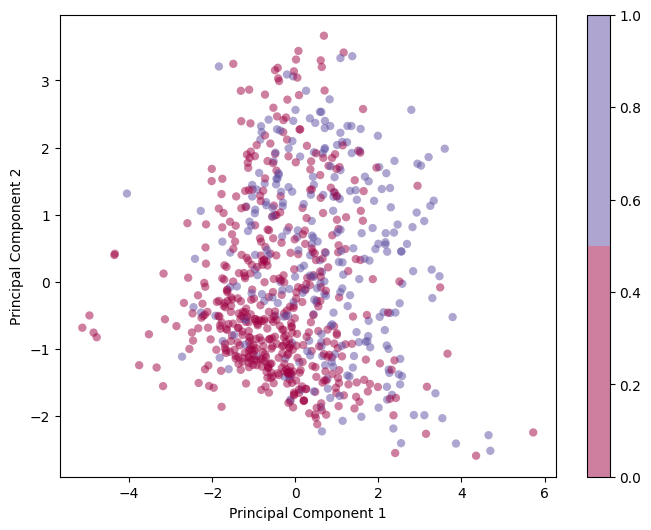

In [12]:
#TODO
plt.figure(figsize=(8,6))
plt.scatter(PC[:, 0], PC[:, 1], c=target, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('Spectral', 2))
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar()
plt.show()

### Do you see any explanation for the selected components

In [13]:
df = pd.DataFrame( columns = raw_features.columns)
df.loc[0] = pca.components_[0,:]
df.loc[1] = pca.components_[1,:]

In [14]:
print(df)

   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.128432  0.393083       0.360003       0.439824  0.435026  0.451941   
1     0.593786  0.174029       0.183892      -0.331965 -0.250781 -0.100960   

   DiabetesPedigreeFunction       Age  
0                  0.270611  0.198027  
1                 -0.122069  0.620589  
